In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Week 2 - Building, Evaluating, and Interpreting ML Models

## Project 1: ML-Powered Customer Analytics

**Student:** Haseeb Sheikh  
**Course:** Introduction to Applied AI  
**Department:** Electronics  
**Week:** 2

### Objective

In this lab, I will train and evaluate different machine learning models to predict customer churn.

The models used in this lab are:

- Baseline Dummy Classifier
- Logistic Regression
- Balanced Logistic Regression
- Decision Tree
- Random Forest

I will also evaluate the models using accuracy, precision, recall, F1-score, and ROC-AUC.

## Part 1: Preprocessing, Train/Test Split, and Baseline

In this part, I will load the Telco Customer Churn dataset, clean the data, convert categorical variables into numerical variables, split the data into training and testing sets, and create a simple baseline model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load dataset

path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Check missing values and data types

print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [5]:
# Convert TotalCharges from text to numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Missing TotalCharges after conversion:")
print(df['TotalCharges'].isnull().sum())

Missing TotalCharges after conversion:
11


In [6]:
# Fill missing TotalCharges values with median

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print("Total missing values after cleaning:")
print(df.isnull().sum().sum())

Total missing values after cleaning:
0


In [7]:
# Create features and target

def build_features(data):
    """
    Drop customer ID and target.
    Convert categorical columns using one-hot encoding.
    """
    
    X = data.drop(columns=['customerID', 'Churn'])
    X = pd.get_dummies(X, drop_first=True).astype(float)
    
    return X


# Target variable
y = (df['Churn'] == 'Yes').astype(int)

# Features
X = build_features(df)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (7043, 30)
Target shape: (7043,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [8]:
# Stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining churn rate:", round(y_train.mean(), 3))
print("Testing churn rate:", round(y_test.mean(), 3))

Training rows: 5634
Testing rows: 1409

Training churn rate: 0.265
Testing churn rate: 0.265


In [9]:
# Baseline model
# This model always predicts the majority class: Stay

dummy = DummyClassifier(
    strategy='most_frequent'
)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_dummy
)

print("Baseline accuracy:", round(baseline_accuracy, 3))

print(
    "Number of actual churners:",
    y_test.sum()
)

print(
    "Number of churners caught by baseline:",
    ((y_pred_dummy == 1) & (y_test == 1)).sum()
)

Baseline accuracy: 0.735
Number of actual churners: 374
Number of churners caught by baseline: 0


### Write It — Part 1

The baseline model predicts the majority class for every customer. Its accuracy is the value calculated above.

It catches zero churners because it always predicts that customers will stay.

This baseline is important because it gives us a simple model to beat. A more advanced model should provide useful information about churn instead of only achieving a high accuracy by predicting the majority class.

# Part 2: Logistic Regression

Logistic Regression is a classification algorithm that predicts the probability of a customer churning.

The model first calculates a weighted sum of the input features and then passes that value through a sigmoid function to produce a probability between 0 and 1.

A Pipeline is used with StandardScaler so that scaling is learned only from the training data.

In [10]:
# Logistic Regression inside a Pipeline

lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Churn probabilities
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=3
    )
)

Logistic Regression Results:
              precision    recall  f1-score   support

           0      0.851     0.894     0.872      1035
           1      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409



In [11]:
# Logistic Regression coefficients and odds ratios

w = lr.named_steps['model'].coef_[0]

coef = pd.DataFrame({
    'feature': X.columns,
    'weight': w,
    'odds_ratio': np.exp(w)
})

coef = coef.sort_values('weight')

print("Five strongest protective factors:")
display(coef.head(5).round(3))

print("\nFive highest risk factors:")
display(coef.tail(5).sort_values(
    'weight',
    ascending=False
).round(3))

Five strongest protective factors:


,feature,weight,odds_ratio
1,tenure,-1.220,0.295
2,MonthlyCharges,-0.921,0.398
25,Contract_Two year,-0.589,0.555
24,Contract_One year,-0.286,0.751
13,OnlineSecurity_Yes,-0.123,0.884



Five highest risk factors:


,feature,weight,odds_ratio
10,InternetService_Fiber optic,0.779,2.179
3,TotalCharges,0.497,1.644
23,StreamingMovies_Yes,0.259,1.295
21,StreamingTV_Yes,0.258,1.294
9,MultipleLines_Yes,0.216,1.242


In [12]:
# Verify the sigmoid calculation manually

scaler = lr.named_steps['scale']
model = lr.named_steps['model']

# Select first test customer
x0 = scaler.transform(
    X_test.iloc[[0]]
)

# Linear score
z = model.intercept_[0] + (
    x0 @ model.coef_[0]
)[0]

# Sigmoid function
p = 1 / (1 + np.exp(-z))

print("Linear score z:", round(z, 3))
print("Manual sigmoid probability:", round(p, 4))
print("Sklearn probability:", round(y_prob_lr[0], 4))

Linear score z: -3.07
Manual sigmoid probability: 0.0444
Sklearn probability: 0.0444


### Write It — Part 2

The Logistic Regression model provides both predictions and churn probabilities.

The odds-ratio table helps explain which features are associated with higher or lower churn odds.

A positive weight gives an odds ratio greater than 1, meaning the feature increases the churn odds when the standardized feature value increases.

A negative weight gives an odds ratio below 1, meaning the feature decreases the churn odds.

The manually calculated sigmoid probability should match the probability produced by scikit-learn.

# Part 3: Confusion Matrix and Evaluation Metrics

A confusion matrix divides predictions into four groups:

- True Negative (TN): customer stayed and model predicted Stay
- False Positive (FP): customer stayed but model predicted Churn
- False Negative (FN): customer churned but model predicted Stay
- True Positive (TP): customer churned and model predicted Churn

We will calculate precision, recall, and F1-score manually and then compare them with scikit-learn.

In [13]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

TN = 925
FP = 110
FN = 162
TP = 212


In [29]:
# Calculate metrics manually

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print("Metrics calculated by hand:")
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

print("\nMetrics from sklearn:")
print("Precision:", round(
    precision_score(y_test, y_pred_lr), 3
))

print("Recall:", round(
    recall_score(y_test, y_pred_lr), 3
))

print("F1-score:", round(
    f1_score(y_test, y_pred_lr), 3
))

Metrics calculated by hand:
Precision: 0.658
Recall: 0.567
F1-score: 0.609

Metrics from sklearn:
Precision: 0.658
Recall: 0.567
F1-score: 0.609


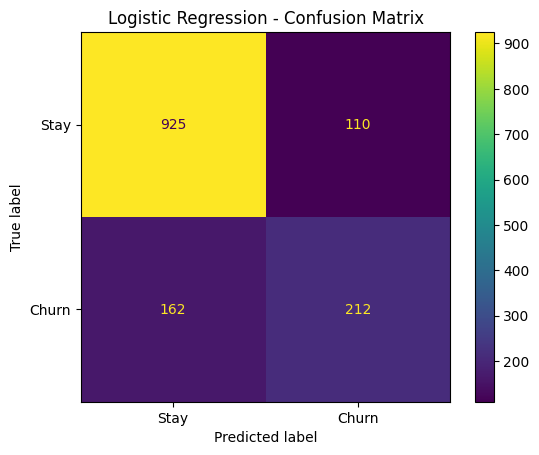

In [14]:
# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stay', 'Churn']
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Write It — Part 3

The confusion matrix shows how many customers were correctly and incorrectly classified.

TN represents customers correctly predicted to stay.

FP represents customers incorrectly flagged as churners.

FN represents churners that the model missed.

TP represents churners correctly detected by the model.

Recall is particularly important in churn prediction because it tells us what percentage of actual churners the model successfully catches.

Accuracy alone can be misleading when one class is much larger than the other.

# Part 4: ROC-AUC, Decision Thresholds, and Business Cost

The Logistic Regression model produces probabilities.

Normally, a probability of 0.5 is used as the classification threshold.

However, changing the threshold changes precision and recall.

In this part, I will examine different thresholds and use business costs to select a threshold.

Logistic Regression ROC-AUC: 0.842


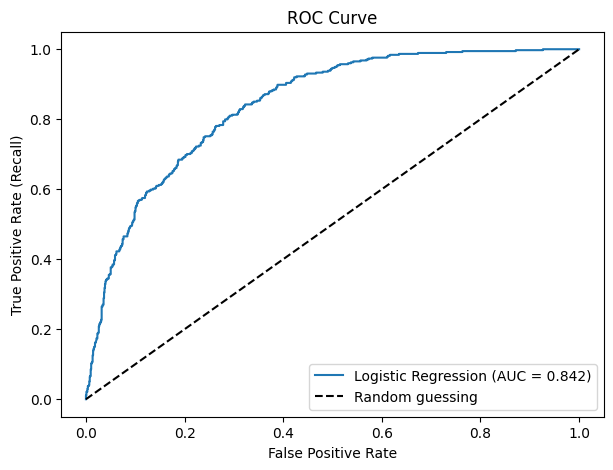

In [15]:
# ROC curve and AUC

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression ROC-AUC:",
      round(auc_lr, 3))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [16]:
# Compare different classification thresholds

rows = []

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:

    pred = (
        y_prob_lr >= t
    ).astype(int)

    rows.append({
        'threshold': t,
        'flagged': int(pred.sum()),
        'precision': precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        'recall': recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        'f1': f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(rows)

display(
    threshold_results.round(3)
)

,threshold,flagged,precision,recall,f1
0,0.2,685,0.467,0.856,0.604
1,0.3,544,0.518,0.754,0.614
2,0.4,441,0.567,0.668,0.613
3,0.5,322,0.658,0.567,0.609
4,0.6,210,0.710,0.398,0.510
5,0.7,89,0.730,0.174,0.281


In [17]:
# Business cost analysis

# Cost assumptions from the lab
C_FN = 6000   # missed churner
C_FP = 1000   # unnecessary retention offer


def total_cost(t):

    pred = (
        y_prob_lr >= t
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    return (
        fn * C_FN +
        fp * C_FP
    )


# Test thresholds
ts = np.arange(
    0.05,
    0.95,
    0.05
)

costs = [
    total_cost(t)
    for t in ts
]

best_t = ts[
    int(np.argmin(costs))
]

theoretical_t = (
    C_FP /
    (C_FP + C_FN)
)

print(
    "Theoretical threshold:",
    round(theoretical_t, 2)
)

print(
    "Empirical best threshold:",
    round(best_t, 2)
)

Theoretical threshold: 0.14
Empirical best threshold: 0.15


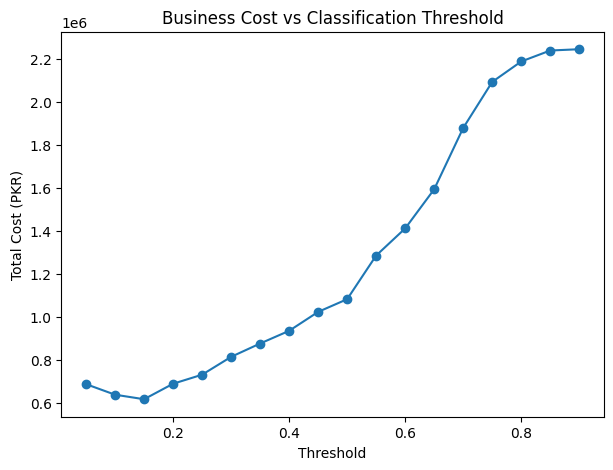

In [18]:
# Plot business cost against threshold

plt.figure(figsize=(7, 5))

plt.plot(
    ts,
    costs,
    marker='o'
)

plt.xlabel('Threshold')
plt.ylabel('Total Cost (PKR)')
plt.title('Business Cost vs Classification Threshold')

plt.show()

In [30]:
# Compare selected threshold with 0.5

pred_05 = (
    y_prob_lr >= 0.5
).astype(int)

pred_best = (
    y_prob_lr >= best_t
).astype(int)

cm_05 = confusion_matrix(
    y_test,
    pred_05
)

cm_best = confusion_matrix(
    y_test,
    pred_best
)

tn05, fp05, fn05, tp05 = cm_05.ravel()
tnb, fpb, fnb, tpb = cm_best.ravel()

print("At threshold 0.5:")
print("Churners caught:", tp05)
print("False alarms:", fp05)
print("Total cost:", total_cost(0.5))

print("\nAt selected threshold:", round(best_t, 2))
print("Churners caught:", tpb)
print("False alarms:", fpb)
print("Total cost:", total_cost(best_t))

print("\nExtra churners caught:",
      tpb - tp05)

print("Extra false alarms:",
      fpb - fp05)

At threshold 0.5:
Churners caught: 212
False alarms: 110
Total cost: 1082000

At selected threshold: 0.15
Churners caught: 344
False alarms: 437
Total cost: 617000

Extra churners caught: 132
Extra false alarms: 327


### Write It — Part 4

The ROC-AUC measures how well the model separates churners from customers who stay across different thresholds.

The classification threshold affects the balance between precision and recall.

In this lab, a missed churner has a higher business cost than an unnecessary retention offer. Therefore, the threshold should consider these business costs instead of automatically using 0.5.

The theoretical threshold and empirical threshold calculated above should be compared.

The final threshold selected for this dataset is the empirical threshold that gives the lowest calculated business cost.

# Part 5: Decision Trees and Random Forests

Decision Trees can model nonlinear relationships, but a deep tree can memorize the training data.

This is called overfitting.

I will test different tree depths and compare training and testing accuracy.

Then I will use a Random Forest, which combines many decision trees.

In [21]:
# Test Decision Tree at different depths

rows = []

depths = [
    1, 2, 3, 4, 5,
    6, 8, 10, 15, None
]

for d in depths:

    dt = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    dt.fit(
        X_train,
        y_train
    )

    rows.append({
        'max_depth': str(d),
        'train_accuracy': dt.score(
            X_train,
            y_train
        ),
        'test_accuracy': dt.score(
            X_test,
            y_test
        )
    })

depth_df = pd.DataFrame(rows)

display(
    depth_df.round(3)
)

,max_depth,train_accuracy,test_accuracy
0,1,0.735,0.735
1,2,0.791,0.787
2,3,0.791,0.787
3,4,0.793,0.796
4,5,0.801,0.794
5,6,0.807,0.797
6,8,0.835,0.780
7,10,0.872,0.756
8,15,0.969,0.737
9,None,0.998,0.742


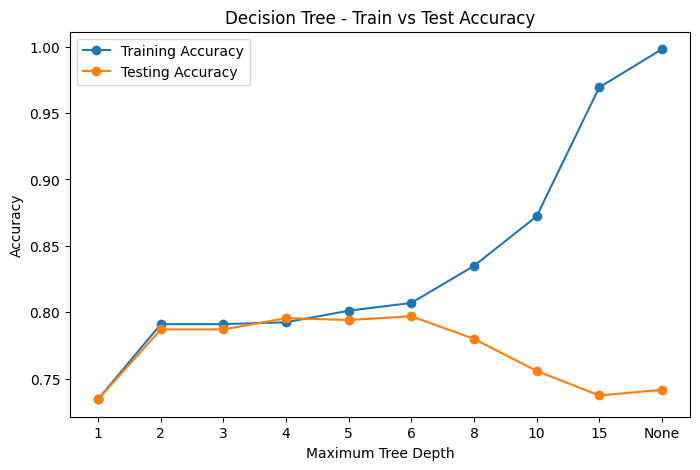

In [31]:
# Plot train vs test accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    depth_df['max_depth'],
    depth_df['train_accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depth_df['max_depth'],
    depth_df['test_accuracy'],
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree - Train vs Test Accuracy')
plt.legend()

plt.show()

In [32]:
# Train regularized Decision Tree

dt5 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

dt5.fit(
    X_train,
    y_train
)

y_pred_dt = dt5.predict(X_test)

y_prob_dt = dt5.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred_dt,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.845     0.884     0.864      1035
           1      0.632     0.551     0.589       374

    accuracy                          0.796      1409
   macro avg      0.738     0.717     0.726      1409
weighted avg      0.788     0.796     0.791      1409



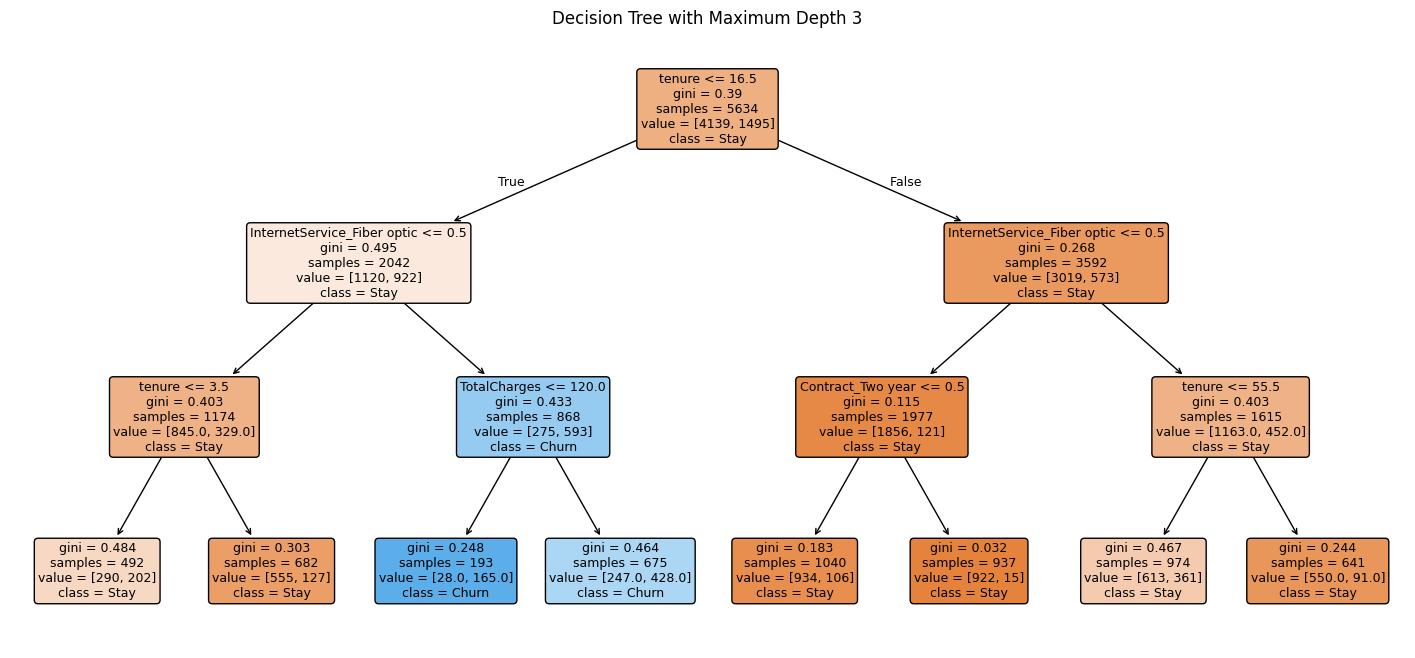

In [33]:
# Plot a shallow tree for interpretation

dt3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt3.fit(
    X_train,
    y_train
)

plt.figure(figsize=(18, 8))

plot_tree(
    dt3,
    feature_names=X.columns,
    class_names=['Stay', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree with Maximum Depth 3")

plt.show()

In [34]:
# Calculate Gini impurity of the root node manually

tree = dt3.tree_

root_samples = tree.n_node_samples[0]
root_values = tree.value[0][0]

stay_count = root_values[0]
churn_count = root_values[1]

p_stay = stay_count / root_samples
p_churn = churn_count / root_samples

gini_manual = (
    1 -
    p_stay**2 -
    p_churn**2
)

print("Root node samples:", root_samples)
print("Stay count:", stay_count)
print("Churn count:", churn_count)

print("P(stay):", round(p_stay, 4))
print("P(churn):", round(p_churn, 4))

print(
    "Manual Gini impurity:",
    round(gini_manual, 4)
)

print(
    "Tree Gini impurity:",
    round(tree.impurity[0], 4)
)

Root node samples: 5634
Stay count: 0.7346467873624423
Churn count: 0.2653532126375577
P(stay): 0.0001
P(churn): 0.0
Manual Gini impurity: 1.0
Tree Gini impurity: 0.3899


In [35]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

y_prob_rf = rf.predict_proba(
    X_test
)[:, 1]

print(
    "Random Forest OOB accuracy:",
    round(rf.oob_score_, 3)
)

print(
    "Random Forest test accuracy:",
    round(
        rf.score(X_test, y_test),
        3
    )
)

print(
    "Random Forest test AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_rf
        ),
        3
    )
)

Random Forest OOB accuracy: 0.803
Random Forest test accuracy: 0.807
Random Forest test AUC: 0.842


In [28]:
# Permutation importance

pi = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp = pd.DataFrame({
    'feature': X.columns,
    'mdi': rf.feature_importances_,
    'permutation': pi.importances_mean
})

imp = imp.sort_values(
    'permutation',
    ascending=False
)

print("Top 10 features by permutation importance:")

display(
    imp.head(10).round(4)
)

Top 10 features by permutation importance:


,feature,mdi,permutation
1,tenure,0.1912,0.0404
3,TotalCharges,0.1657,0.0206
25,Contract_Two year,0.0581,0.0164
10,InternetService_Fiber optic,0.0717,0.0132
24,Contract_One year,0.0333,0.0059
28,PaymentMethod_Electronic check,0.0608,0.0031
26,PaperlessBilling_Yes,0.0217,0.0014
0,SeniorCitizen,0.0120,0.0012
9,MultipleLines_Yes,0.0160,0.0009
15,OnlineBackup_Yes,0.0173,0.0006


In [36]:
# Train-test gap at maximum depth

none_row = depth_df[
    depth_df['max_depth'] == 'None'
].iloc[0]

train_none = none_row['train_accuracy']
test_none = none_row['test_accuracy']

gap_none = (
    train_none -
    test_none
)

print("Training accuracy at depth None:",
      round(train_none, 3))

print("Testing accuracy at depth None:",
      round(test_none, 3))

print("Train-test gap:",
      round(gap_none, 3))

Training accuracy at depth None: 0.998
Testing accuracy at depth None: 0.742
Train-test gap: 0.256


### Write It — Part 5

The Decision Tree depth experiment shows how increasing tree depth affects training and testing performance.

When training accuracy continues increasing while testing accuracy stops improving or decreases, the model is showing overfitting.

The Random Forest combines many decision trees and generally provides more stable predictions.

Permutation importance is useful because it evaluates how much the test ROC-AUC changes when a feature is shuffled.

For the final report, I will mention the actual overfitting depth, the train-test gap at depth None, and the top three permutation-importance features from the results above.

# Part 6: Class Imbalance and Feature Engineering

The Telco dataset contains more customers who stay than customers who churn.

Because of this class imbalance, I will compare normal Logistic Regression with Logistic Regression using class_weight='balanced'.

I will also create new features based on the EDA from Week 1.

In [37]:
# Balanced Logistic Regression

lr_bal = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_bal.fit(
    X_train,
    y_train
)

y_pred_bal = lr_bal.predict(
    X_test
)

y_prob_bal = lr_bal.predict_proba(
    X_test
)[:, 1]

print("Balanced Logistic Regression:")
print(
    classification_report(
        y_test,
        y_pred_bal,
        digits=3
    )
)

Balanced Logistic Regression:
              precision    recall  f1-score   support

           0      0.901     0.724     0.803      1035
           1      0.505     0.781     0.613       374

    accuracy                          0.739      1409
   macro avg      0.703     0.752     0.708      1409
weighted avg      0.796     0.739     0.753      1409



In [38]:
# Compare default and balanced Logistic Regression

comparison_balanced = pd.DataFrame([
    {
        'model': 'LR default',
        'precision': precision_score(
            y_test,
            y_pred_lr
        ),
        'recall': recall_score(
            y_test,
            y_pred_lr
        ),
        'f1': f1_score(
            y_test,
            y_pred_lr
        )
    },
    {
        'model': 'LR balanced',
        'precision': precision_score(
            y_test,
            y_pred_bal
        ),
        'recall': recall_score(
            y_test,
            y_pred_bal
        ),
        'f1': f1_score(
            y_test,
            y_pred_bal
        )
    }
])

display(
    comparison_balanced.round(3)
)

,model,precision,recall,f1
0,LR default,0.658,0.567,0.609
1,LR balanced,0.505,0.781,0.613


In [39]:
# Feature engineering

df2 = df.copy()

svc = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Number of services
df2['n_services'] = (
    df2[svc] == 'Yes'
).sum(axis=1)

# New customer indicator
df2['is_new'] = (
    df2['tenure'] <= 12
).astype(int)

# Approximate monthly charge from total charges
df2['charge_per_mo'] = (
    df2['TotalCharges'] /
    df2['tenure'].clip(lower=1)
)

# Difference between actual monthly charge
# and calculated average monthly charge
df2['price_jump'] = (
    df2['MonthlyCharges'] -
    df2['charge_per_mo']
)

display(
    df2[
        [
            'n_services',
            'is_new',
            'charge_per_mo',
            'price_jump'
        ]
    ].head()
)

,n_services,is_new,charge_per_mo,price_jump
0,1,1,29.850000,0.000000
1,3,0,55.573529,1.376471
2,3,1,54.075000,-0.225000
3,3,0,40.905556,1.394444
4,1,1,75.825000,-5.125000


In [40]:
# Build engineered feature dataset

X2 = build_features(df2)

# Keep exactly the same train/test rows
X2_train = X2.loc[X_train.index]
X2_test = X2.loc[X_test.index]

print("Original features:", X.shape)
print("Engineered features:", X2.shape)

Original features: (7043, 30)
Engineered features: (7043, 34)


In [41]:
# Random Forest using engineered features

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf2.fit(
    X2_train,
    y_train
)

y_prob_rf2 = rf2.predict_proba(
    X2_test
)[:, 1]

auc_before = roc_auc_score(
    y_test,
    y_prob_rf
)

auc_after = roc_auc_score(
    y_test,
    y_prob_rf2
)

print("Random Forest AUC before:",
      round(auc_before, 4))

print("Random Forest AUC after:",
      round(auc_after, 4))

print("AUC change:",
      round(auc_after - auc_before, 4))

Random Forest AUC before: 0.8422
Random Forest AUC after: 0.842
AUC change: -0.0002


### Write It — Part 6

Balanced class weights change the importance given to the two classes during Logistic Regression training.

The main purpose is to improve the model's ability to detect the minority class, which can increase recall while sometimes reducing precision.

The engineered features were evaluated using the same train/test split as the original Random Forest.

If the AUC increased, the engineered features improved the model according to AUC.

If the AUC did not increase, this is still a valid result. It may mean that the Random Forest was already able to capture similar information from the original features.

# Part 7: Model Comparison

In this final part, I will compare the baseline, Logistic Regression, balanced Logistic Regression, Decision Tree, and Random Forest using five metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [42]:
# Function to evaluate models

def evaluate(name, pred, prob):

    return {
        'model': name,
        'accuracy': accuracy_score(
            y_test,
            pred
        ),
        'precision': precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        'recall': recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        'f1': f1_score(
            y_test,
            pred,
            zero_division=0
        ),
        'auc': roc_auc_score(
            y_test,
            prob
        )
    }


# Model comparison table

results = pd.DataFrame([
    
    evaluate(
        'Baseline',
        dummy.predict(X_test),
        dummy.predict_proba(X_test)[:, 1]
    ),
    
    evaluate(
        'Logistic Regression',
        y_pred_lr,
        y_prob_lr
    ),
    
    evaluate(
        'LR balanced',
        y_pred_bal,
        y_prob_bal
    ),
    
    evaluate(
        'Decision Tree (d=5)',
        y_pred_dt,
        y_prob_dt
    ),
    
    evaluate(
        'Random Forest',
        y_pred_rf,
        y_prob_rf
    )
]).round(3)

display(results)

,model,accuracy,precision,recall,f1,auc
0,Baseline,0.735,0.000,0.000,0.000,0.500
1,Logistic Regression,0.807,0.658,0.567,0.609,0.842
2,LR balanced,0.739,0.505,0.781,0.613,0.841
3,Decision Tree (d=5),0.796,0.632,0.551,0.589,0.829
4,Random Forest,0.807,0.673,0.529,0.593,0.842


In [43]:
# Save comparison table

results.to_csv(
    'week2_model_comparison.csv',
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


## Final Model Analysis

The comparison table shows the performance of all five models.

When interpreting the results, I consider:

1. ROC-AUC for overall ranking ability.
2. Recall because detecting churners is important.
3. Precision because unnecessary retention offers have a business cost.
4. F1-score as a balance between precision and recall.
5. Model interpretability and practical business use.

The final model and threshold should be selected using the actual metrics and business costs calculated in this notebook rather than assuming that one metric alone is sufficient.